In [ ]:
!pip install icecream
!pip install segmentation_models_pytorch

In [ ]:
import os
from osgeo import gdal
import numpy as np
from icecream import ic # icecream is a debugging tool. See https://github.com/gruns/icecream
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import torch.nn as nn


## Download data

Dataset is in https://drive.google.com/file/d/1AUkcQzHuB6EMa0OBMAahYRzxl_Vtik0-/view?usp=drive_link

In [ ]:
!gdown --i 1AUkcQzHuB6EMa0OBMAahYRzxl_Vtik0-


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AUkcQzHuB6EMa0OBMAahYRzxl_Vtik0-
To: /content/images.rar
100% 24.9M/24.9M [00:00<00:00, 160MB/s]


In [ ]:
!unrar -y x "/content/images.rar"
os.remove("/content/images.rar")



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/images.rar

Extracting  images/Images_Test/Image_Test.tif                             16% 33% 50% 58%  OK 
Extracting  images/Images_Test/Reference_Test.tif                         60%  OK 
Extracting  images/Images_Train/Image_Train.tif                           76% 93% 99%  OK 
Extracting  images/Images_Train/Reference_Train.tif                       99%  OK 
All OK


In [ ]:
train_input_path = "/content/images/Images_Train/Image_Train.tif"
train_reference_path = "/content/images/Images_Train/Reference_Train.tif"

test_input_path = "/content/images/Images_Test/Image_Test.tif"
test_reference_path = "/content/images/Images_Test/Reference_Test.tif"


In [ ]:
def read_tiff(tiff_file):
    data = gdal.Open(tiff_file).ReadAsArray()
    data = np.transpose(data, (1, 2, 0))
    return data

In [ ]:
im_train = read_tiff(train_input_path)
reference_train_rgb = read_tiff(train_reference_path)

im_test = read_tiff(test_input_path)
reference_test_rgb = read_tiff(test_reference_path)

ic(im_train.shape, reference_train_rgb.shape)
ic(im_test.shape, reference_test_rgb.shape)


ic| im_train.shape: (2565, 1919, 3)
    reference_train_rgb.shape: (2565, 1919, 3)
ic| im_test.shape: (2558, 2818, 3)
    reference_test_rgb.shape: (2558, 2818, 3)


((2558, 2818, 3), (2558, 2818, 3))

## Classes are:

0.   Impervious surfaces (RGB: 255, 255, 255)
1.   Building (RGB: 0, 0, 255)
2.   Low vegetation (RGB: 0, 255, 255)
3.   Tree (RGB: 0, 255, 0)
4.   Car (RGB: 255, 255, 0)







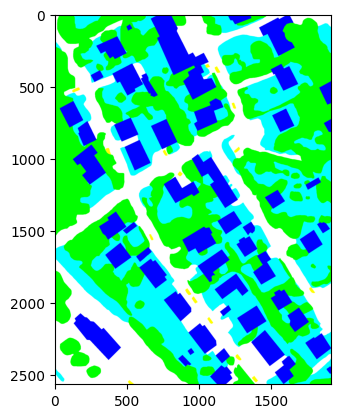

In [ ]:
plt.imshow(reference_train_rgb)

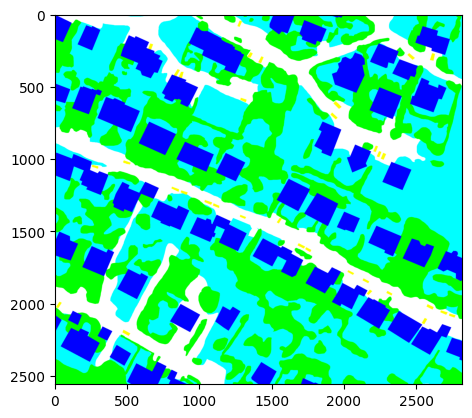

In [ ]:
plt.imshow(reference_test_rgb)

## Utilities to convert reference from RGB to grayscale and from grayscale to RGB

In [ ]:

def label_rgb_to_grayscale(msk):

    msk = msk.astype(np.int64)
    new = np.zeros((msk.shape[0], msk.shape[1]), dtype=np.int64)

    msk = msk // 255
    msk = msk * (1, 7, 49)
    msk = msk.sum(axis=2)

    new[msk == 1 + 7 + 49] = 0 # Street.
    new[msk ==         49] = 1 # Building.
    new[msk ==     7 + 49] = 2 # Grass.
    new[msk ==     7     ] = 3 # Tree.
    new[msk == 1 + 7     ] = 4 # Car.
    new[msk == 1         ] = 5 # Surfaces.
    new[msk == 0         ] = 6 # Boundaries.

    return new

colormap = {0: [255, 255, 255],
            1: [0, 0, 255],
            2: [0, 255, 255],
            3: [0, 255, 0],
            4: [255, 255, 0]}

def label_grayscale_to_rgb(label):

    msk = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)

    for c in colormap.keys():
      msk[..., 0][label == c] = colormap[c][0]
      msk[..., 1][label == c] = colormap[c][1]
      msk[..., 2][label == c] = colormap[c][2]

    return msk

In [ ]:
reference_train = label_rgb_to_grayscale(reference_train_rgb)
reference_test = label_rgb_to_grayscale(reference_test_rgb)


In [ ]:
ic(reference_train.shape)

ic| reference_train.shape: (2565, 1919)


(2565, 1919)

## Visualize dataset

ic| np.unique(reference_train, return_counts=True): (array([0, 1, 2, 3, 4]), array([1132698,  867583, 1255273, 1653521,   13160]))
ic| np.unique(reference_test, return_counts=True): (array([0, 1, 2, 3, 4]), array([1185224, 1302768, 2549104, 2144306,   27042]))


Text(0.5, 1.0, 'reference test')

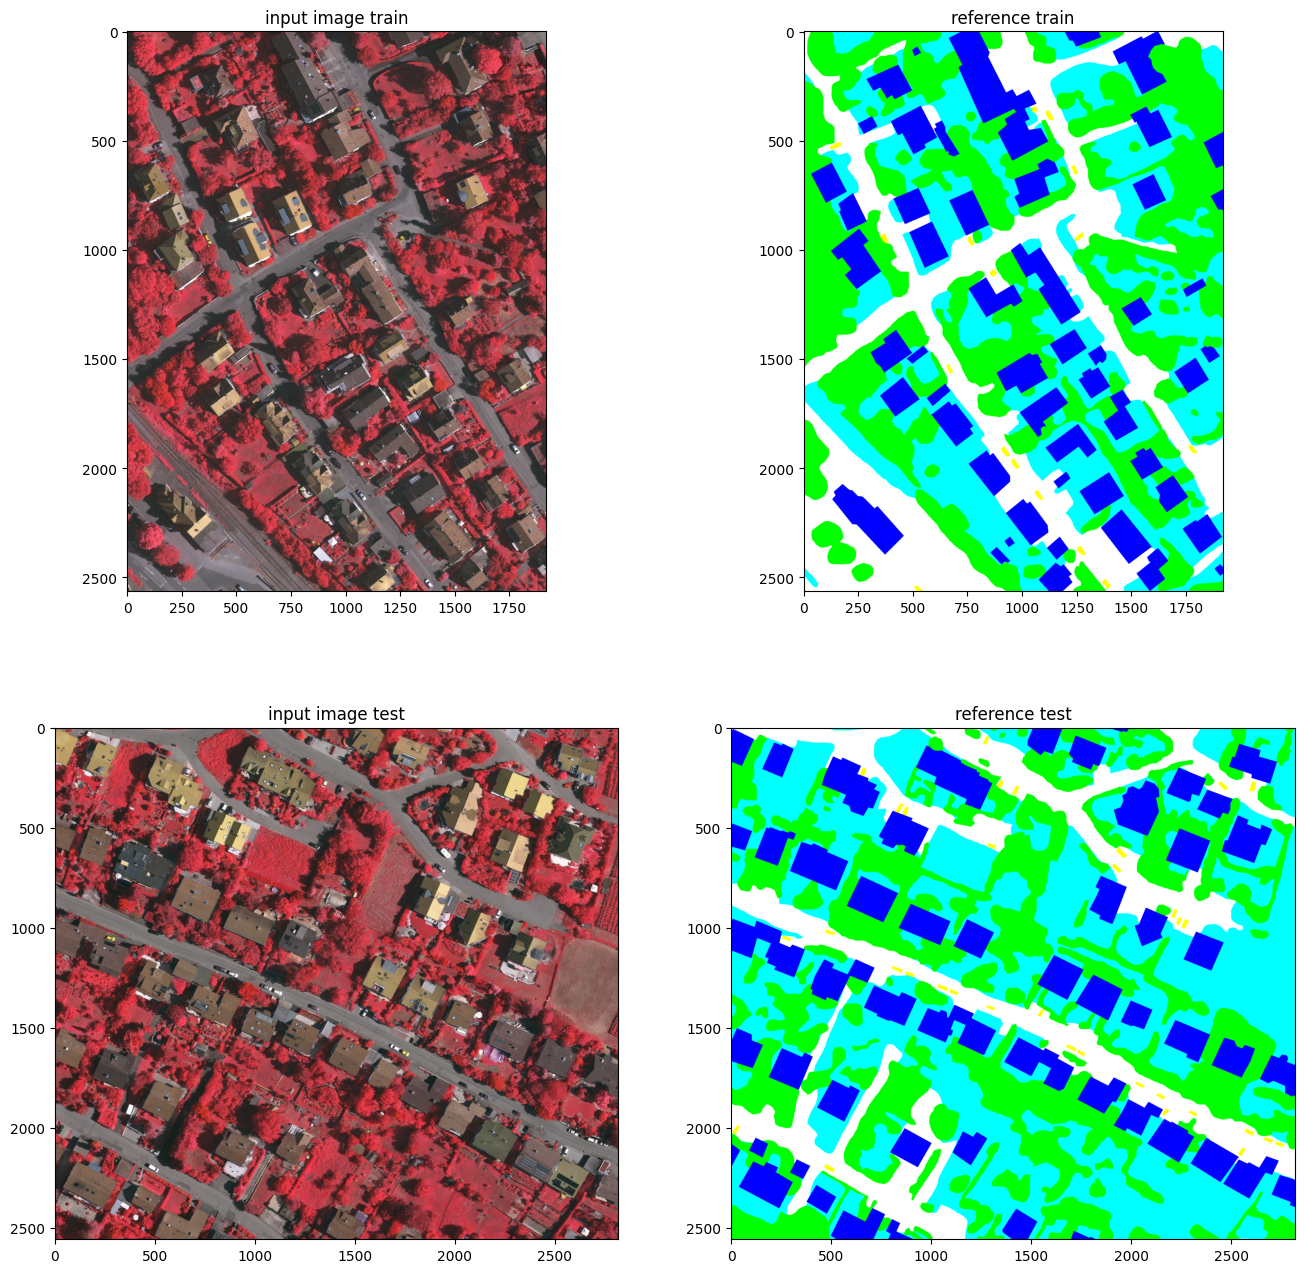

In [ ]:
ic(np.unique(reference_train, return_counts=True))
ic(np.unique(reference_test, return_counts=True))

plt.figure(figsize=(16, 16))
plt.subplot(221)
plt.imshow(im_train/255)
plt.title('input image train')
plt.subplot(222)
plt.imshow(reference_train_rgb)
plt.title('reference train')

plt.subplot(223)
plt.imshow(im_test/255)
plt.title('input image test')

plt.subplot(224)
plt.imshow(reference_test_rgb)
plt.title('reference test')

## Extract image patches

We use `view_as_windows` from `skimage`. See the documentation https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.view_as_windows

In [ ]:
from skimage.util import view_as_windows
channel_n = 3
patch_len = 128

train_step = patch_len//2

ic(im_train.shape)

im_train_patch = view_as_windows(im_train, (patch_len, patch_len, channel_n), step=train_step)
reference_train_patch = view_as_windows(reference_train, (patch_len, patch_len), step=train_step)

#del im_train, reference_train

im_train_patch = im_train_patch.reshape(-1, patch_len, patch_len, channel_n)
reference_train_patch = reference_train_patch.reshape(-1, patch_len, patch_len)

ic(im_train_patch.shape)
ic(reference_train_patch.shape)

print("Number of training patches:", im_train_patch.shape[0])

ic| im_train.shape: (2565, 1919, 3)


Number of training patches: 1092


ic| im_train_patch.shape: (1092, 128, 128, 3)
ic| reference_train_patch.shape: (1092, 128, 128)


## Convert labels to one-hot


In [ ]:
class_n = len(np.unique(reference_train))
ic(np.unique(reference_test))
def to_one_hot(reference, class_n):
    b = np.zeros((reference.size, class_n))
    b[np.arange(reference.size), reference.astype(np.int64)] = 1
    return b

def patches_to_one_hot(reference_patch, class_n):
    shape = reference_patch.shape
    reference_patch = to_one_hot(reference_patch.flatten(), class_n)
    reference_patch = reference_patch.reshape((*shape, class_n))
    return reference_patch

reference_train_patch = patches_to_one_hot(reference_train_patch, class_n)
ic(reference_train_patch.shape)
ic(class_n)


# 0
# [1 0 0 0 0]

ic| np.unique(reference_test): array([0, 1, 2, 3, 4])
ic| reference_train_patch.shape: (1092, 128, 128, 5)
ic| class_n: 5


5

## Split training patches into 80% for training and 20% for validation

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import torch

# Assuming your train input and reference are already tensors
train_input = im_train_patch
train_reference = reference_train_patch

# Split data into training and validation sets (80%/20%)
train_input, val_input, train_reference, val_reference = train_test_split(train_input, train_reference, test_size=0.2, random_state=42)


## Define the Pytorch DataLoader for training and validation

Hint: Remember to normalize the input images. Each encoder has its own normalization parameters, obtained as:

`params = smp.encoders.get_preprocessing_params(encoder_name)`

Where mean and std parameters will be `params['mean']` and `params['std']`, respectively.

See the class hands-on for more details.

In [ ]:
from torchvision import transforms
import segmentation_models_pytorch as smp

encoder_name = 'resnet50'
params = smp.encoders.get_preprocessing_params(encoder_name)
mean = params['mean'] # [0.4, 0.4, 0.4]
std = params['std'] # [0.1, 0.1, 0.1]

def check_type(x):
    if isinstance(x, torch.Tensor):
        return "PyTorch Tensor"
    elif isinstance(x, np.ndarray):
        return "NumPy Array"
    else:
        return "Unknown type"

# Define separate datasets for training and validation
class CustomDataset(Dataset):
    def __init__(self, input, reference, transform=None, transform_reference=None):
        self.input = input
        self.reference = reference
        self.transform = transform
        self.transform_reference = transform_reference
    def __len__(self):
        return len(self.input)

    def __getitem__(self, idx):
        image = self.input[idx]
        label = self.reference[idx]
        # print("0 np.unique(label, return_counts=True)", np.unique(label, return_counts=True))

        if label.ndim == 3 and label.shape[2] > 1:
           label = np.argmax(label, axis=2)
        # print("1 np.unique(label, return_counts=True)", np.unique(label, return_counts=True))

        # Apply the transform to the image
        if self.transform is not None:
          image = self.transform(image)


        if self.transform_reference is not None:
          label = self.transform_reference(label)
          # label = torch.tensor(label, dtype=torch.long)

        # print("2 np.unique(label, return_counts=True)", np.unique(label, return_counts=True))

        return image, label


# Define a transform that first converts the image to a tensor and then normalizes it
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to tensor
    transforms.Normalize(mean=mean, std=std)  # Normalize
])

transform_reference = transforms.ToTensor()

# Create training and validation dataset instances
train_dataset = CustomDataset(train_input, train_reference, transform=transform, transform_reference=transform_reference)
val_dataset = CustomDataset(val_input, val_reference, transform=transform, transform_reference=transform_reference)


# Create separate DataLoaders for training and validation
train_batch_size = 64 # Adjust batch_size as needed
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False)  # Don't shuffle validation data



## Define your model using SMP

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_n = 5

# Estrutura utilizada em "U-Net: Convolutional Networks for Biomedical Image Segmentation":
# filtro 3x3, função não linear ReLU, max pooling de 2x2, stride de 2 para downsampling.
# a cada downsampling, o número de features dobra.
# a camada final de convolução 1x1.
# total de 23 camadas de convolução.

# You: Define model architecture

#Encoder // Downsampling
class UNet_Encoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=64):
        super().__init__()

        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )

        self.encoder2 = nn.Sequential(
            nn.Conv2d(out_channels, 2*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(2*out_channels, 2*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )

        self.encoder3 = nn.Sequential(
            nn.Conv2d(2*out_channels, 4*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(4*out_channels, 4*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )

        self.encoder4 = nn.Sequential(
            nn.Conv2d(4*out_channels, 8*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(8*out_channels, 8*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )

        self.encoder5 = nn.Sequential(
            nn.Conv2d(8*out_channels, 16*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(16*out_channels, 16*out_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )

        self.down_sample = nn.MaxPool2d(kernel_size=2, stride=2)

    # forward deve ficar **fora do __init__**, no mesmo nível da classe
    def forward(self, X):
        X1 = self.encoder1(X)
        X2 = self.encoder2(self.down_sample(X1))
        X3 = self.encoder3(self.down_sample(X2))
        X4 = self.encoder4(self.down_sample(X3))
        X5 = self.encoder5(self.down_sample(X4))
        return X5, X4, X3, X2, X1

  # Decoder // Upsampling

class UNet_Decoder(nn.Module):
  def __init__(self, out_channels=64):
    super().__init__()

    self.decoder1 = nn.Conv2d(out_channels, 3, 3, stride=1, padding=1)

    self.decoder2 = nn.Sequential(nn.Conv2d(2*out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU()
                                  )
    self.decoder3 = nn.Sequential(nn.Conv2d(4*out_channels, 2*out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(2*out_channels, 2*out_channels, kernel_size=3, padding=1, stride=1),
                                  nn.ReLU()
                                  )
    self.decoder4 = nn.Sequential(nn.Conv2d(8*out_channels, 4*out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(4*out_channels, 4*out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU()
                                  )
    self.decoder5 = nn.Sequential(nn.Conv2d(16*out_channels, 8*out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(8*out_channels, 8*out_channels, kernel_size=3, stride=1, padding=1),
                                  nn.ReLU()
                                  )

    self.up_sample_54 = nn.ConvTranspose2d(16*out_channels, 8*out_channels, kernel_size=2, stride=2)
    self.up_sample_43 = nn.ConvTranspose2d(8*out_channels, 4*out_channels, kernel_size=2, stride=2)
    self.up_sample_32 = nn.ConvTranspose2d(4*out_channels, 2*out_channels, kernel_size=2, stride=2)
    self.up_sample_21 = nn.ConvTranspose2d(2*out_channels, out_channels, kernel_size=2, stride=2)

  def forward(self, X5, X4, X3, X2, X1):
    X = self.up_sample_54(X5)
    X4 = torch.cat([X, X4], dim=1) #dim=1 -> 1 representa a dimesão de canais
    X4 = self.decoder5(X4)

    X = self.up_sample_43(X4)
    X3 = torch.cat([X, X3], dim=1)
    X3 = self.decoder4(X3)

    X = self.up_sample_32(X3)
    X2 = torch.cat([X, X2], dim=1)
    X2 = self.decoder3(X2)

    X = self.up_sample_21(X2)
    X1 = torch.cat([X, X1], dim=1)
    X1 = self.decoder2(X1)

    dec4 = self.decoder1(X1)

    return X

class UNet(nn.Module):
  def __init__(self, class_n = 5):
    super().__init__()

    self.down = UNet_Encoder()
    self.up = UNet_Decoder()

    self.final_conv = nn.Conv2d(64, class_n, kernel_size=1)


  def forward(self, X):
    X5, X4, X3, X2, X1 = self.down(X)
    X = self.up(X5, X4, X3, X2, X1)
    X = self.final_conv(X)

    return X


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(class_n=5).to(device)

x = torch.randn(1, 3, 128, 128).to(device)
y = model(x)

print("Input:", x.shape)
print("Output:", y.shape)

Input: torch.Size([1, 3, 128, 128])
Output: torch.Size([1, 5, 128, 128])


## Definition of early stopping.

Use as in the next example https://github.com/Bjarten/early-stopping-pytorch/blob/master/MNIST_Early_Stopping_example.ipynb

In [ ]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func
    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

## Define your training loop.

1. You can reuse code from the class hands-on https://colab.research.google.com/drive/1XVEgeZotsafKc5cQJI8I4_sPygcsd_q4?usp=sharing

2. The next link contains another training example using Pytorch. Use early stopping on the validation set as in https://github.com/Bjarten/early-stopping-pytorch/blob/master/MNIST_Early_Stopping_example.ipynb


In [ ]:
'''
# Training loop (example)
for train_batch, reference_batch in train_loader:
    # Your training logic here
    # ...
'''

lr = 0.001
model_name = smp.Unet
encoder_name = 'resnet50'
encoder_weights = 'imagenet'
classes = 5

m = model_name(encoder_name= encoder_name,
               encoder_weights= encoder_weights,
               classes = classes)

params = smp.encoders.get_preprocessing_params(encoder_name)
mean = params['mean']
std = params['std']

print(f"Normalization mean: {params['mean']}, std: {params['std']}")

Normalization mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]


In [ ]:
def prediction_accuracy(ground_truth_labels, predicted_labels):
    eq = ground_truth_labels == predicted_labels
    return eq.sum().item() / predicted_labels.numel()

In [ ]:
def get_model_parameters(m):
    total_params = sum(
        param.numel() for param in m.parameters()
    )
    return total_params

def print_model_parameters(m):
    num_model_parameters = get_model_parameters(m)
    print(f"The Model has {num_model_parameters/1e6:.2f}M parameters")

In [ ]:
print_model_parameters(m)

The Model has 32.52M parameters


Verificar segmentação

In [ ]:
from enum import IntEnum

class TrimapClasses(IntEnum):
    Street = 0
    Biulding = 1
    Grass = 2
    Tree = 3
    Car = 4
    Surfaces = 5
    Boundaries = 6


In [ ]:
from torchvision import transforms
import torchvision.transforms as T

# Convert a pytorch tensor into a PIL image
t2img = T.ToPILImage()
# Convert a PIL image into a pytorch tensor
img2t = T.ToTensor()

def t2img(tensor):
  return transforms.ToPILImage()(tensor)

In [ ]:
def trimap2f(trimap):
    return (img2t(trimap) * 255.0 - 1) / 2

def print_test_dataset_masks

In [ ]:
!pip install torchmetrics

In [ ]:
# =====================  VISUALIZAÇÃO E MÉTRICAS  =====================
import os
import torch
import torchmetrics as TM
import torchvision
import matplotlib.pyplot as plt

def close_figures():
    while len(plt.get_fignums()):
        plt.close()

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_n  = 5                      # número de classes
cm_ignore = None                  # ex.: 0 se quiser ignorar background

@torch.no_grad()
def print_test_dataset_masks(model,
                             val_loader,
                             epoch:int,
                             save_path:str=None,
                             max_sample:int=3,
                             device=device,
                             show_plot:bool=True):
    """
    • Calcula Pixel-Accuracy e IoU
    • Mostra até `max_sample` exemplos
    """
    model.eval().to(device)

    img_samples, gt_samples, pred_samples = [], [], []
    all_preds, all_targets = [], []

    for images, masks in val_loader:
        images = images.to(device)
        masks  = masks.to(device)                      # [B, C, H, W]  (one-hot)

        logits = model(images)                         # [B, C, H, W]
        preds  = torch.softmax(logits, dim=1).argmax(1)  # [B,1,H,W] ??

        # converte alvo one-hot para índices
        targets_idx = masks.argmax(1)    # [B,1,H,W] ??
        print("targets_idx.shape", targets_idx.shape)
       #targets_idx = masks.unsqueeze(1)

        all_preds.append(preds.cpu())
        all_targets.append(targets_idx.cpu())

        if len(img_samples) < max_sample:
            img_samples.append(images.cpu())
            gt_samples.append(targets_idx.cpu())
            pred_samples.append(preds.cpu())


    # concatena tudo em tensores grandes
    pred_tensor   = torch.cat(all_preds,   0).to(device)     # [N,1,H,W]
    target_tensor = torch.cat(all_targets, 0).to(device)     # [N,1,H,W]

    pred_idx   = pred_tensor
    target_idx = target_tensor

    iou_metric = TM.classification.MulticlassJaccardIndex(
                    num_classes=class_n,
                    average='micro',
                    ignore_index=cm_ignore).to(device)
    acc_metric = TM.classification.MulticlassAccuracy(
                    num_classes=class_n,
                    average='micro',
                    ignore_index=cm_ignore).to(device)

    iou_val = iou_metric(pred_idx, target_idx)
    acc_val = acc_metric(pred_idx, target_idx)

    title = f'Epoch {epoch:02d} | PixelAcc: {acc_val:.4f}  IoU: {iou_val:.4f}'
    print(title)

    # -------- Visualização ----------
    close_figures()
    fig = plt.figure(figsize=(10, 12))
    fig.suptitle(title, fontsize=12)

    # Imagens
    fig.add_subplot(3, 1, 1)
    img_grid = torchvision.utils.make_grid(torch.cat(img_samples, 0), nrow=max_sample)
    plt.imshow(t2img(img_grid)); plt.axis('off'); plt.title('Imagens')

    # GT
    fig.add_subplot(3, 1, 2)
    print("gt_samples[0].shape", gt_samples[0].shape)
    gt_grid = torchvision.utils.make_grid(torch.cat(gt_samples, 0).float()/class_n,
                                          nrow=max_sample)
    print("gt_grid.shape", gt_grid.shape)
    plt.imshow(t2img(gt_grid)); plt.axis('off'); plt.title('GT (índices)')

    # Predições
    fig.add_subplot(3, 1, 3)
    pred_grid = torchvision.utils.make_grid(torch.cat(pred_samples, 0).unsqueeze(1).float()/class_n,
                                            nrow=max_sample)
    plt.imshow(t2img(pred_grid)); plt.axis('off'); plt.title('Predições')

    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, f'epoch_{epoch:02d}.png'),
                    dpi=150, bbox_inches='tight', pad_inches=0.4)

    if show_plot:
        plt.show()
    else:
        close_figures()
# =====================================================================


loop de treinamento

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(m.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.7)

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid


# Choose colors per class (BGR/RGB tuples 0–255). Add/adjust for your class_n.
PALETTE = np.array([
    [255, 255, 255],  # 0
    [0, 0, 255],  # 1
    [0, 255, 255],  # 2
    [0, 255, 0],  # 3
    [255, 255, 0],  # 4
], dtype=np.uint8)  # shape [C,3]

def colorize_idx(idx_2d: torch.Tensor, palette=PALETTE) -> np.ndarray:
    """idx_2d: [H,W] (Long). Returns RGB uint8 [H,W,3]."""
    idx_np = idx_2d.detach().cpu().numpy()
    idx_np = np.clip(idx_np, 0, len(palette)-1)
    return palette[idx_np]  # broadcasting

def chw_to_hwc_uint8(img: torch.Tensor) -> np.ndarray:
    """
    img: [3,H,W] float/uint8. Heuristics to map to [0..255] uint8 for plotting.
    """
    x = img.detach().cpu()
    if x.dtype != torch.float32 and x.dtype != torch.float64:
        x = x.float()
    # If normalized (e.g., [-2,2]), bring to [0,1]
    x_min, x_max = float(x.min()), float(x.max())
    if x_max <= 1.0 and x_min >= 0.0:
        pass  # already [0,1]
    else:
        # try to guess if it's [0,255]
        if x_max > 1.5 and x_max <= 255.0:
            x = x / 255.0
        else:
            # generic min-max to [0,1]
            x = (x - x_min) / (x_max - x_min + 1e-8)
    x = (x.clamp(0,1) * 255.0).byte()
    return x.permute(1,2,0).numpy()  # [H,W,3]

@torch.no_grad()
def visualize_one_sample(model,
                         val_loader,
                         device,
                         epoch:int,
                         save_path:str=None,
                         sample_from_batch:int=0):
    """
    Grabs one batch from val_loader, picks `sample_from_batch`, runs prediction,
    and saves/displays (Image | GT | Pred) for this epoch.
    """
    model.eval().to(device)

    # ---- take first batch from val_loader ----
    images, masks = next(iter(val_loader))  # images: [B,3,H,W]  masks: [B,H,W] or [B,C,H,W]
    images = images.to(device)
    masks  = masks.to(device)

    # one-hot -> indices
    if masks.dim() == 4:   # [B,C,H,W]
        masks_idx = masks.argmax(1)
    elif masks.dim() == 3: # [B,H,W]
        masks_idx = masks.long()
    else:
        raise ValueError(f"Unexpected masks dim={masks.dim()}")

    # choose a sample index that exists
    s = min(sample_from_batch, images.size(0)-1)

    # ---- forward & pred ----
    logits = model(images)                 # [B,C,H,W]
    preds  = logits.softmax(1).argmax(1)   # [B,H,W]

    # ---- extract one sample ----
    img_chw = images[s]                    # [3,H,W]
    gt_idx  = masks_idx[s]                 # [H,W]
    pr_idx  = preds[s]                     # [H,W]

    img_rgb = chw_to_hwc_uint8(img_chw)
    gt_rgb  = colorize_idx(gt_idx)
    pr_rgb  = colorize_idx(pr_idx)

    # ---- plot ----
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_rgb); axes[0].set_title("Image");     axes[0].axis('off')
    axes[1].imshow(gt_rgb);  axes[1].set_title("GT (idx)");  axes[1].axis('off')
    axes[2].imshow(pr_rgb);  axes[2].set_title("Pred (idx)");axes[2].axis('off')
    fig.suptitle(f"Epoch {epoch:02d}")

    if save_path is not None:
        import os
        os.makedirs(save_path, exist_ok=True)
        out_file = os.path.join(save_path, f"viz_epoch_{epoch:02d}.png")
        plt.savefig(out_file, dpi=150, bbox_inches='tight')
        print(f"[viz] saved: {out_file}")

    plt.show()
    model.train()

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()          # coloca o modelo em modo treino
    model.to(device)       # envia o modelo para o device

    criterion = nn.CrossEntropyLoss(reduction='mean')
    running_loss = 0.0
    running_samples = 0

    for batch_idx, (inputs, targets) in enumerate(loader):
        # print("0 torch.unique(targets)", torch.unique(targets))
        optimizer.zero_grad()
        inputs = inputs.to(device)
        targets = targets.to(device)



        outputs = model(inputs)
        # print("outputs.shape", outputs.shape)
        # print("targets.shape", targets.shape)

        # print(" torch.unique(torch.argmax(outputs, dim=1))", torch.unique(torch.argmax(outputs, dim=1), return_counts=True))
        # print("torch.unique(targets)", torch.unique(targets, return_counts=True))

        # print("2 torch.unique(targets)", torch.unique(targets))

        # remove a dimensão de canal se os targets forem [N,1,H,W]
        if targets.dim() == 4 and targets.size(1) == 1:
            targets = targets.squeeze(1)

        #print("outputs.shape:", outputs.shape)

        loss = criterion(outputs, targets)
        loss.backward() # calcula os gradientes
        optimizer.step() # atualiza os parâmetros


        running_loss += loss.item() * inputs.size(0)
        running_samples += inputs.size(0)

    # fim do loop
    print("Trained {} samples, Loss: {:.4f}".format(
        running_samples,
        running_loss / running_samples
        ))


In [ ]:
def train_model(model, loader, val_loader, num_epochs, optimizer, scheduler, save_path=None, plot_every=5):

  model.to(device)

  for epoch in range(1, num_epochs + 1):
      print(f"\nEpoch {epoch}/{num_epochs}, learning rate: {optimizer.param_groups[0]['lr']:.6f}")

      # treina uma época
      train_one_epoch(model, loader, optimizer, device)

      # atualiza scheduler depois do optimizer.step()
      # if scheduler is not None:
      #     scheduler.step()

      # visualiza resultados do val_loader a cada plot_every épocas
      # if epoch % plot_every == 0:
      #     print(f"Visualizando resultados na época {epoch}...")
      #     print_test_dataset_masks(model, val_loader, epoch, save_path, max_sample=3, device=device, show_plot=True)
      if epoch % plot_every == 0:
            visualize_one_sample(model, val_loader, device, epoch,
                                 save_path=save_path, sample_from_batch=0)
print("\nTreino finalizado!")


Treino finalizado!


In [ ]:
print(im_train.shape)  # Teria que ser [N, C, H, W] ?
print(reference_train.shape)

(2565, 1919, 3)
(2565, 1919)


In [ ]:
image = torch.tensor(im_train, dtype=torch.float32)  # (H, W, C)
image = image.unsqueeze(0)                            # (1, H, W, C)
image = image.permute(0, 3, 1, 2)

target = torch.tensor(reference_train, dtype=torch.long).unsqueeze(0)  # [1, 2565, 1919]


In [ ]:
print(image.shape)  # Teria que ser [N, C, H, W] ?
print(target.shape)

torch.Size([1, 3, 2565, 1919])
torch.Size([1, 2565, 1919])



Epoch 1/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.3204
Trained 128 samples, Loss: 0.3079
Trained 192 samples, Loss: 0.3048
Trained 256 samples, Loss: 0.2936
Trained 320 samples, Loss: 0.2937
Trained 384 samples, Loss: 0.2909
Trained 448 samples, Loss: 0.2843
Trained 512 samples, Loss: 0.2883
Trained 576 samples, Loss: 0.2869
Trained 640 samples, Loss: 0.2875
Trained 704 samples, Loss: 0.2821
Trained 768 samples, Loss: 0.2810
Trained 832 samples, Loss: 0.2801
Trained 873 samples, Loss: 0.2797

Epoch 2/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2971
Trained 128 samples, Loss: 0.4201
Trained 192 samples, Loss: 0.4661
Trained 256 samples, Loss: 0.5756
Trained 320 samples, Loss: 0.5703
Trained 384 samples, Loss: 0.5753
Trained 448 samples, Loss: 0.5842
Trained 512 samples, Loss: 0.5731
Trained 576 samples, Loss: 0.5601
Trained 640 samples, Loss: 0.5470
Trained 704 samples, Loss: 0.5500
Trained 768 samples, Loss: 0.5528
Trained 832 samples, Loss: 0.5535
Trained 87

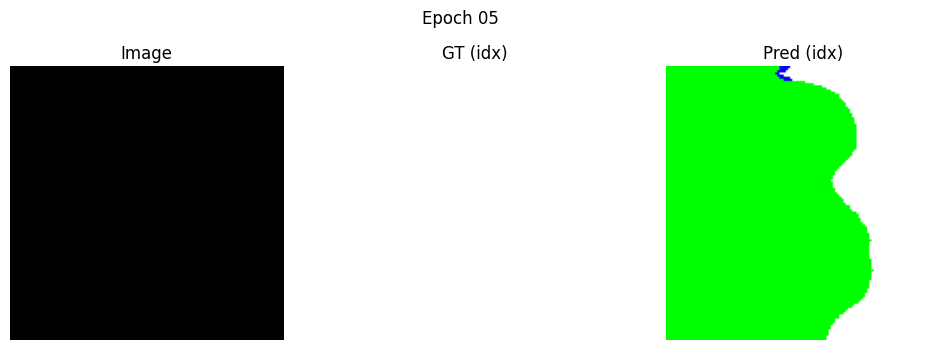


Epoch 6/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.3204
Trained 128 samples, Loss: 0.2994
Trained 192 samples, Loss: 0.2976
Trained 256 samples, Loss: 0.2899
Trained 320 samples, Loss: 0.2832
Trained 384 samples, Loss: 0.2803
Trained 448 samples, Loss: 0.2748
Trained 512 samples, Loss: 0.2728
Trained 576 samples, Loss: 0.2719
Trained 640 samples, Loss: 0.2683
Trained 704 samples, Loss: 0.2656
Trained 768 samples, Loss: 0.2656
Trained 832 samples, Loss: 0.2627
Trained 873 samples, Loss: 0.2612

Epoch 7/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.3009
Trained 128 samples, Loss: 0.2786
Trained 192 samples, Loss: 0.2596
Trained 256 samples, Loss: 0.2690
Trained 320 samples, Loss: 0.2663
Trained 384 samples, Loss: 0.2601
Trained 448 samples, Loss: 0.2543
Trained 512 samples, Loss: 0.2610
Trained 576 samples, Loss: 0.2575
Trained 640 samples, Loss: 0.2622
Trained 704 samples, Loss: 0.2576
Trained 768 samples, Loss: 0.2593
Trained 832 samples, Loss: 0.2576
Trained 87

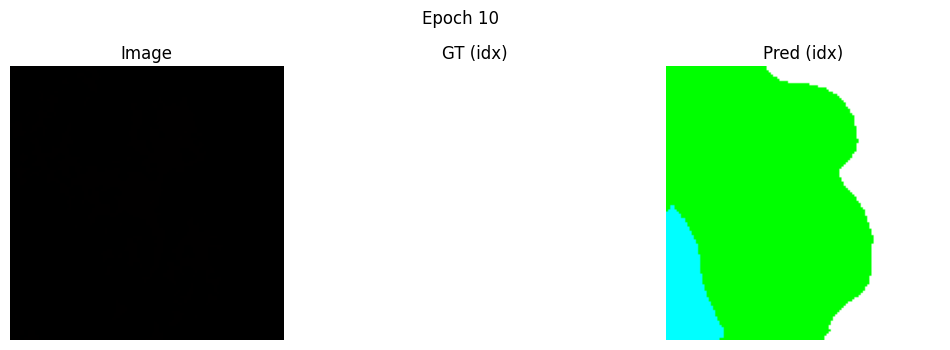


Epoch 11/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2274
Trained 128 samples, Loss: 0.1917
Trained 192 samples, Loss: 0.1820
Trained 256 samples, Loss: 0.1764
Trained 320 samples, Loss: 0.1753
Trained 384 samples, Loss: 0.1717
Trained 448 samples, Loss: 0.1706
Trained 512 samples, Loss: 0.1668
Trained 576 samples, Loss: 0.1645
Trained 640 samples, Loss: 0.1632
Trained 704 samples, Loss: 0.1640
Trained 768 samples, Loss: 0.1624
Trained 832 samples, Loss: 0.1628
Trained 873 samples, Loss: 0.1618

Epoch 12/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2592
Trained 128 samples, Loss: 0.2055
Trained 192 samples, Loss: 0.1866
Trained 256 samples, Loss: 0.1754
Trained 320 samples, Loss: 0.1675
Trained 384 samples, Loss: 0.1624
Trained 448 samples, Loss: 0.1605
Trained 512 samples, Loss: 0.1590
Trained 576 samples, Loss: 0.1562
Trained 640 samples, Loss: 0.1553
Trained 704 samples, Loss: 0.1516
Trained 768 samples, Loss: 0.1500
Trained 832 samples, Loss: 0.1487
Trained 

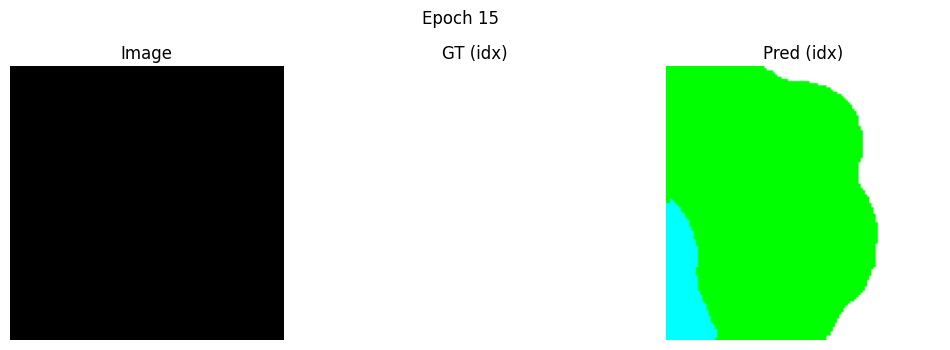


Epoch 16/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1894
Trained 128 samples, Loss: 0.2002
Trained 192 samples, Loss: 0.1871
Trained 256 samples, Loss: 0.1877
Trained 320 samples, Loss: 0.1833
Trained 384 samples, Loss: 0.1779
Trained 448 samples, Loss: 0.1778
Trained 512 samples, Loss: 0.1705
Trained 576 samples, Loss: 0.1715
Trained 640 samples, Loss: 0.1678
Trained 704 samples, Loss: 0.1655
Trained 768 samples, Loss: 0.1628
Trained 832 samples, Loss: 0.1602
Trained 873 samples, Loss: 0.1602

Epoch 17/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2604
Trained 128 samples, Loss: 0.2102
Trained 192 samples, Loss: 0.1858
Trained 256 samples, Loss: 0.1761
Trained 320 samples, Loss: 0.1665
Trained 384 samples, Loss: 0.1619
Trained 448 samples, Loss: 0.1591
Trained 512 samples, Loss: 0.1567
Trained 576 samples, Loss: 0.1540
Trained 640 samples, Loss: 0.1531
Trained 704 samples, Loss: 0.1503
Trained 768 samples, Loss: 0.1488
Trained 832 samples, Loss: 0.1486
Trained 

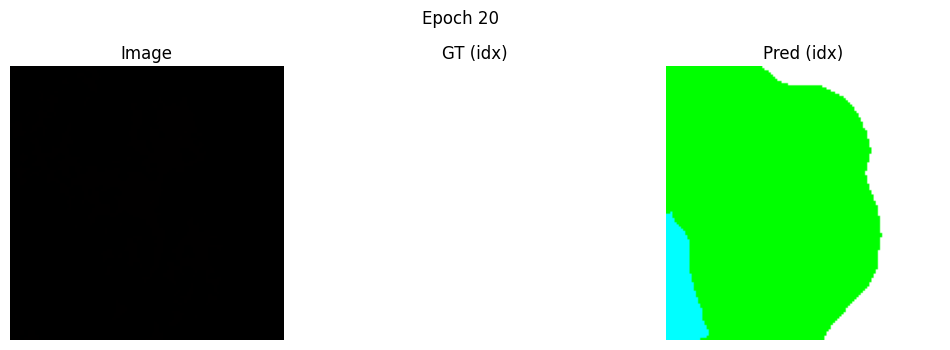


Epoch 21/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1649
Trained 128 samples, Loss: 0.1315
Trained 192 samples, Loss: 0.1183
Trained 256 samples, Loss: 0.1115
Trained 320 samples, Loss: 0.1095
Trained 384 samples, Loss: 0.1086
Trained 448 samples, Loss: 0.1064
Trained 512 samples, Loss: 0.1051
Trained 576 samples, Loss: 0.1038
Trained 640 samples, Loss: 0.1030
Trained 704 samples, Loss: 0.1017
Trained 768 samples, Loss: 0.1012
Trained 832 samples, Loss: 0.1004
Trained 873 samples, Loss: 0.0999

Epoch 22/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2038
Trained 128 samples, Loss: 0.1462
Trained 192 samples, Loss: 0.1267
Trained 256 samples, Loss: 0.1184
Trained 320 samples, Loss: 0.1128
Trained 384 samples, Loss: 0.1074
Trained 448 samples, Loss: 0.1048
Trained 512 samples, Loss: 0.1026
Trained 576 samples, Loss: 0.1019
Trained 640 samples, Loss: 0.0999
Trained 704 samples, Loss: 0.0994
Trained 768 samples, Loss: 0.0983
Trained 832 samples, Loss: 0.0976
Trained 

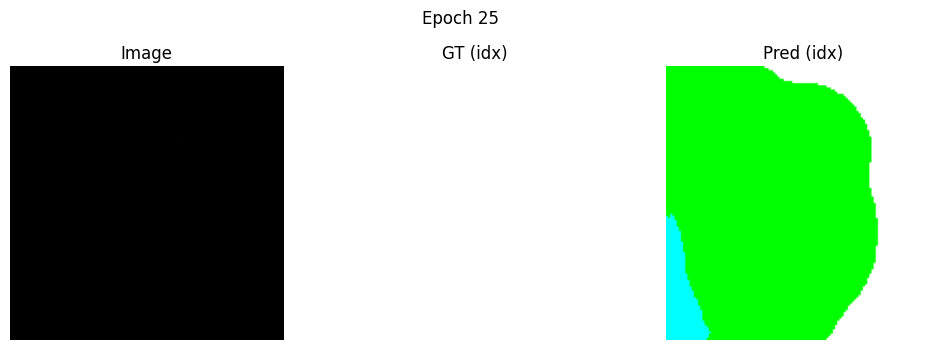


Epoch 26/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2353
Trained 128 samples, Loss: 0.1819
Trained 192 samples, Loss: 0.1493
Trained 256 samples, Loss: 0.1389
Trained 320 samples, Loss: 0.1300
Trained 384 samples, Loss: 0.1225
Trained 448 samples, Loss: 0.1200
Trained 512 samples, Loss: 0.1150
Trained 576 samples, Loss: 0.1132
Trained 640 samples, Loss: 0.1105
Trained 704 samples, Loss: 0.1086
Trained 768 samples, Loss: 0.1071
Trained 832 samples, Loss: 0.1074
Trained 873 samples, Loss: 0.1060

Epoch 27/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1614
Trained 128 samples, Loss: 0.1734
Trained 192 samples, Loss: 0.1575
Trained 256 samples, Loss: 0.1908
Trained 320 samples, Loss: 0.2120
Trained 384 samples, Loss: 0.2006
Trained 448 samples, Loss: 0.2043
Trained 512 samples, Loss: 0.2085
Trained 576 samples, Loss: 0.2111
Trained 640 samples, Loss: 0.2140
Trained 704 samples, Loss: 0.2135
Trained 768 samples, Loss: 0.2124
Trained 832 samples, Loss: 0.2079
Trained 

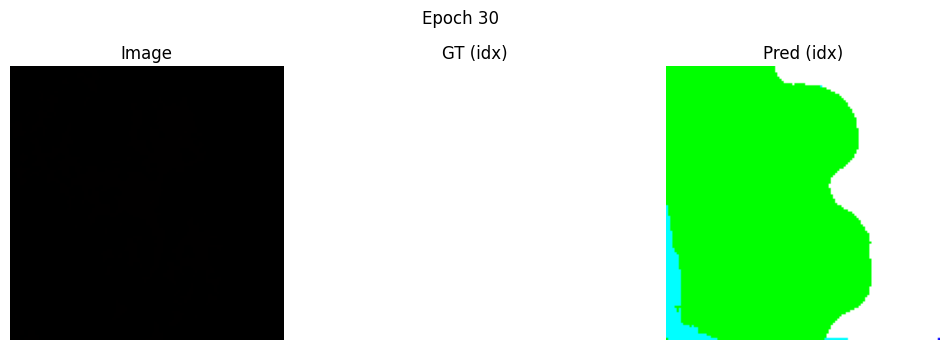


Epoch 31/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.4527
Trained 128 samples, Loss: 0.4700
Trained 192 samples, Loss: 0.4608
Trained 256 samples, Loss: 0.4635
Trained 320 samples, Loss: 0.4510
Trained 384 samples, Loss: 0.4383
Trained 448 samples, Loss: 0.4372
Trained 512 samples, Loss: 0.4324
Trained 576 samples, Loss: 0.4305
Trained 640 samples, Loss: 0.4281
Trained 704 samples, Loss: 0.4233
Trained 768 samples, Loss: 0.4214
Trained 832 samples, Loss: 0.4174
Trained 873 samples, Loss: 0.4184

Epoch 32/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.3090
Trained 128 samples, Loss: 0.3789
Trained 192 samples, Loss: 0.3817
Trained 256 samples, Loss: 0.3856
Trained 320 samples, Loss: 0.3881
Trained 384 samples, Loss: 0.3819
Trained 448 samples, Loss: 0.3754
Trained 512 samples, Loss: 0.3738
Trained 576 samples, Loss: 0.3767
Trained 640 samples, Loss: 0.3761
Trained 704 samples, Loss: 0.3762
Trained 768 samples, Loss: 0.3710
Trained 832 samples, Loss: 0.3660
Trained 

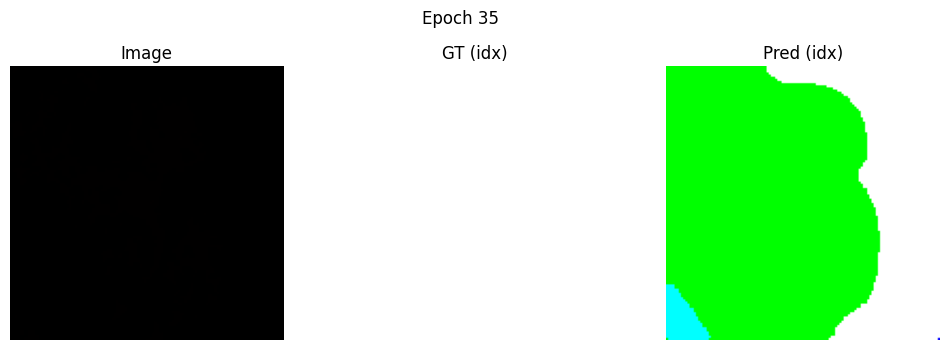


Epoch 36/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2457
Trained 128 samples, Loss: 0.2052
Trained 192 samples, Loss: 0.1863
Trained 256 samples, Loss: 0.1824
Trained 320 samples, Loss: 0.1727
Trained 384 samples, Loss: 0.1708
Trained 448 samples, Loss: 0.1672
Trained 512 samples, Loss: 0.1658
Trained 576 samples, Loss: 0.1643
Trained 640 samples, Loss: 0.1624
Trained 704 samples, Loss: 0.1613
Trained 768 samples, Loss: 0.1599
Trained 832 samples, Loss: 0.1583
Trained 873 samples, Loss: 0.1567

Epoch 37/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.2214
Trained 128 samples, Loss: 0.1980
Trained 192 samples, Loss: 0.1848
Trained 256 samples, Loss: 0.1725
Trained 320 samples, Loss: 0.1665
Trained 384 samples, Loss: 0.1640
Trained 448 samples, Loss: 0.1584
Trained 512 samples, Loss: 0.1571
Trained 576 samples, Loss: 0.1545
Trained 640 samples, Loss: 0.1514
Trained 704 samples, Loss: 0.1503
Trained 768 samples, Loss: 0.1484
Trained 832 samples, Loss: 0.1464
Trained 

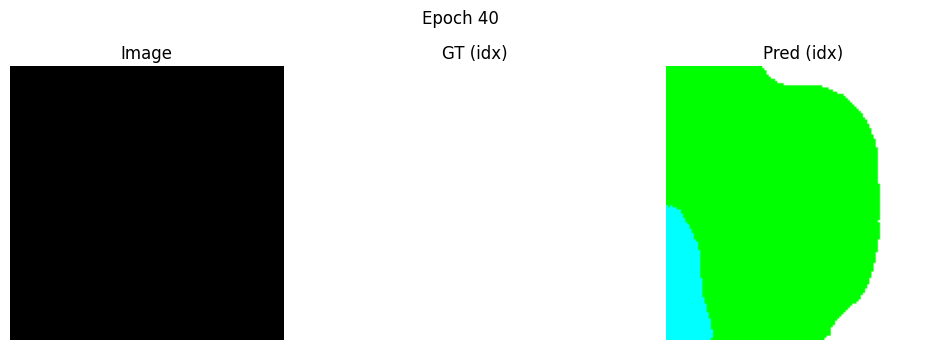


Epoch 41/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1588
Trained 128 samples, Loss: 0.1291
Trained 192 samples, Loss: 0.1129
Trained 256 samples, Loss: 0.1096
Trained 320 samples, Loss: 0.1049
Trained 384 samples, Loss: 0.1021
Trained 448 samples, Loss: 0.0997
Trained 512 samples, Loss: 0.0980
Trained 576 samples, Loss: 0.0966
Trained 640 samples, Loss: 0.0953
Trained 704 samples, Loss: 0.0950
Trained 768 samples, Loss: 0.0943
Trained 832 samples, Loss: 0.0935
Trained 873 samples, Loss: 0.0927

Epoch 42/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1561
Trained 128 samples, Loss: 0.1244
Trained 192 samples, Loss: 0.1106
Trained 256 samples, Loss: 0.1022
Trained 320 samples, Loss: 0.1012
Trained 384 samples, Loss: 0.0980
Trained 448 samples, Loss: 0.0992
Trained 512 samples, Loss: 0.0971
Trained 576 samples, Loss: 0.0953
Trained 640 samples, Loss: 0.0940
Trained 704 samples, Loss: 0.0927
Trained 768 samples, Loss: 0.0912
Trained 832 samples, Loss: 0.0911
Trained 

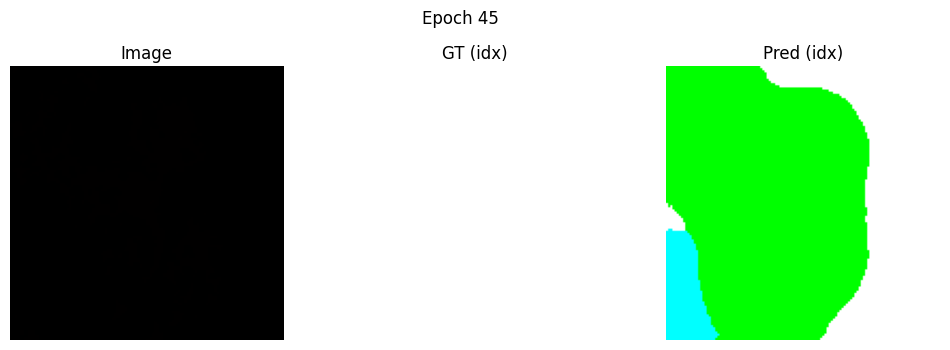


Epoch 46/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1413
Trained 128 samples, Loss: 0.1199
Trained 192 samples, Loss: 0.1078
Trained 256 samples, Loss: 0.1057
Trained 320 samples, Loss: 0.1033
Trained 384 samples, Loss: 0.1006
Trained 448 samples, Loss: 0.0994
Trained 512 samples, Loss: 0.0990
Trained 576 samples, Loss: 0.0975
Trained 640 samples, Loss: 0.0974
Trained 704 samples, Loss: 0.0967
Trained 768 samples, Loss: 0.0951
Trained 832 samples, Loss: 0.0944
Trained 873 samples, Loss: 0.0946

Epoch 47/50, learning rate: 0.001000
Trained 64 samples, Loss: 0.1392
Trained 128 samples, Loss: 0.1205
Trained 192 samples, Loss: 0.1091
Trained 256 samples, Loss: 0.1011
Trained 320 samples, Loss: 0.0978
Trained 384 samples, Loss: 0.0948
Trained 448 samples, Loss: 0.0926
Trained 512 samples, Loss: 0.0910
Trained 576 samples, Loss: 0.0904
Trained 640 samples, Loss: 0.0892
Trained 704 samples, Loss: 0.0879
Trained 768 samples, Loss: 0.0869
Trained 832 samples, Loss: 0.0858
Trained 

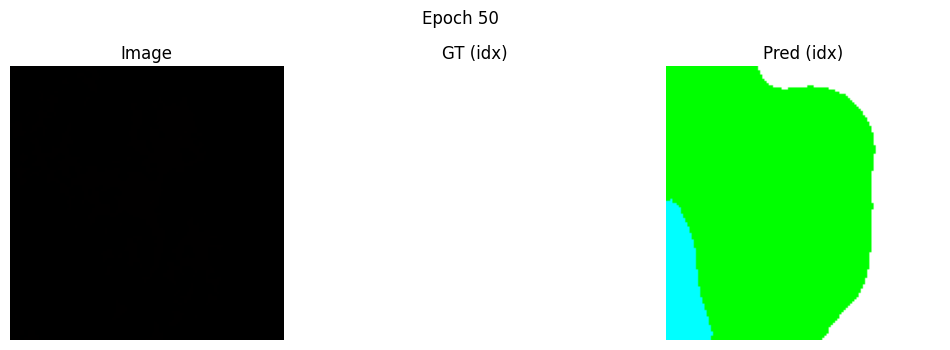

Execution time: 631.5455303192139


In [ ]:
import time

t0 = time.time()
train_model(
    m, # model,
    train_loader,
    val_loader,
    num_epochs=20,  # total de épocas
    optimizer=optimizer,
    scheduler=scheduler,

    plot_every=2     # mostra predições a cada 5 épocas
)
print("Execution time:", time.time() - t0)

## Evaluate the test set

The function `patch_inference()` performs inference on an image using a patch-based approach. If you have any problems with this function, please contact me at cmjorgeandres@gmail.com.

In [ ]:
def patch_inference(image, model, patch_len, overlap_percentage, class_n, device):

    """
    This function performs inference on an image using a patch-based approach.

    Args:
        image: A NumPy array representing the input image. Expected shape is (height, width, channels).
        model: A PyTorch model for making predictions on image patches.
        patch_len: The size (length and width) of square image patches to use.
        overlap_percentage: The percentage overlap between consecutive patches (0 to 1).

    Returns:
        A NumPy array representing the predicted probability map for each class.
        The shape will match the original image.
    """
    model.to(device)
    model.eval()

    rows, cols, _ = image.shape
    """
    Everything  in this function is made operating with
    the upper left corner of the patch
    """

    # Percent of overlap between consecutive patches.
    overlap = round(patch_len * overlap_percentage)
    overlap -= overlap % 2
    stride = patch_len - overlap
    # Add Padding to the image to match with the patch size
    step_row = (stride - rows % stride) % stride
    step_col = (stride - cols % stride) % stride
    pad_tuple_msk = ( (overlap//2, overlap//2 + step_row), ((overlap//2, overlap//2 + step_col)), (0,0) )
    image_pad = np.pad(image, pad_tuple_msk, mode = 'symmetric')
    row_pad, col_pad, _ = image_pad.shape

    output_mosaic = np.zeros((row_pad,col_pad,class_n))

    k1, k2 = (rows+step_row)//stride, (cols+step_col)//stride
    print('Total number of patches: %d x %d' %(k1, k2))


    for i in range(k1):
        for j in range(k2):

            # Get input image patch
            patch = image_pad[i*stride:i*stride + patch_len, j*stride:j*stride + patch_len] # shape: (patch_len, patch_len, class_n)

            patch = np.transpose(patch, (2, 0, 1)) # shape: (class_n, patch_len, patch_len)
            patch = patch.reshape((1,channel_n,patch_len,patch_len)) # shape: (1, class_n, patch_len, patch_len)

            # convert patch to Torch tensor
            patch = torch.from_numpy(patch).float()
            patch = patch.to(device)

            pred_prob_patch = model(patch)

            # print("pred_prob_patch.shape", pred_prob_patch.shape)
            # print("torch.unique(torch.argmax(pred_prob_patch, dim=1), return_counts=True)", torch.unique(torch.argmax(pred_prob_patch, dim=1), return_counts=True))
            pred_prob_patch = pred_prob_patch.squeeze().cpu().detach().numpy().squeeze() # shape: (class_n, patch_len, patch_len)


            pred_prob_patch = np.transpose(pred_prob_patch, (1,2,0)) # shape: (patch_len, patch_len, class_n)

            output_mosaic[i*stride:i*stride + patch_len, j*stride:j*stride + patch_len,:] = pred_prob_patch.copy()
    output_mosaic = output_mosaic[:image.shape[0], :image.shape[1]] # unpad result
    return output_mosaic

`overlap_percentage` indicates the amount of overlap between inference sub-images. A larger overlap may yield a better result, but may result in higher processing times.

Hint: Remember to normalize the input images before running inference. Each encoder has its own normalization parameters, obtained as:

`params = smp.encoders.get_preprocessing_params(encoder_name)`

Where mean and std parameters will be `params['mean']` and `params['std']`, respectively.

See the class hands-on for more details.

In [ ]:
def normalize_image(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
  img = img/255.0
  for channel in range(3):
    img[..., channel] -= mean[channel]
    img[..., channel] /= std[channel]
  return img

In [ ]:
im_test_norm = normalize_image(im_test, mean=mean, std=std) # You: Normalize input image




In [ ]:
overlap_percentage = 0.

result = patch_inference(im_test_norm, m, patch_len=128,
                                    overlap_percentage=overlap_percentage,
                                    class_n=class_n,
                                    device=device)
result = result[:im_test_norm.shape[0], :im_test_norm.shape[1]]

Total number of patches: 20 x 23


In [ ]:
result.shape

(2558, 2818, 5)

In [ ]:
np.unique(result, return_counts=True)

(array([-21.46243095, -21.45941734, -21.45531845, ...,  11.4573431 ,
         11.45741558,  11.45859146]),
 array([1, 1, 1, ..., 1, 1, 1]))

In [ ]:
result = result.argmax(axis=-1)

In [ ]:
result.shape

(2558, 2818)

In [ ]:
np.unique(result, return_counts=True)

(array([0, 1, 2, 3, 4]), array([1403066, 1368646, 1798861, 2625177,   12694]))

In [ ]:
result.shape

(2558, 2818)

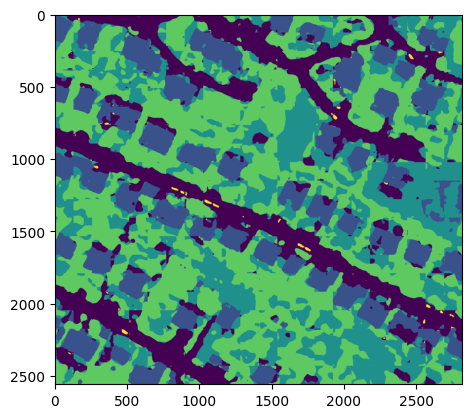

In [ ]:
plt.imshow(result)

## Calculate test metrics
Metrics must be calculated on the reconstructed (large) image

Hint: Use sklearn library

* Accuracy: sklearn.metrics.accuracy_score https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
* F1-score: sklearn.metrics.f1_score: Use average=None for individual per-class values. Use average='macro' for class average F1-score. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
* mIoU: sklearn.metrics.jaccard_score: Use average='macro' for mIoU (Mean intersection over union) https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html

In [ ]:
# You: Calculate test metrics. Hint: Use sklearn library
# Use as "y_true" the variable "reference_test", and as "y_pred" the variable "result"
